# Preparing data for fire impact analysis

This notebook demonstrates the process for processing input data for use with the fire impacts library.

The process is largely automated and, in many cases, the data is downloaded automatically from the publisher.

There are a few things that you will need, however:

* A catchment boundary for your area of interest (eg Shapefile, GeoJSON)
* A suitable, high resolution DEM for the area. The 1" SRTM derived DEM-H is a good option for most cases.
* The date of a fire event within the catchment,
* Several other datasets that you will need to manually download and store locally


## Installation

You will need a Python installation with the various libaries installed.

As a starting point, a base scientific Python installation that includes `numpy`, `pandas`, `jupyter`, `matplotlib`. For Windows users, the easiest way to set up such an environment is to use Anaconda Python, or miniconda.

This base environment should be extended with specific libraries that are used by the fire impacts library. These are listed in `requirements.txt` and can be installed using `pip` from a command prompt:

```
cd <directory-with-library>
pip install -r requirements.txt
```

Finally, the fire impacts library itself should be installed. If you have cloned the git repository, you can install from your local copy. From the command prompt:

```
cd <directory-with-library>
pip install -e .
```

When the installation has completed, the following import statements should run without error

In [1]:
from fire_impacts import FireImpactsProject

In [2]:
from fire_impacts.pre import project, topography, severity, soil, rusle

## Logging

We use logging statements to provide feedback on progress through various steps. This allows you to tailor what level of information you see by setting a log 'level':

* `DEBUG`: Low level information about progress
* `INFO`: General progress updates
* `WARNING`: Problems or potential problems that the system can handle
* `EROR`: Problems that prevent the system from running correctly

When you set a log level, you will see those messages as well as the more serious ones. So if you choose `INFO`, you will also see `WARNING` and `ERROR` messages. If you choose `WARNING`, you will also see `ERROR`.

In [3]:
import logging
logging.basicConfig(level=logging.INFO,format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

## Projects

We organise all the data related to a study in a project directory. This should generally be a *new* directory that will be populated with data that has been computed with the library. The library will manage the subdirectories and data within the main project directory.

In Python, we use a `FireImpactsProject` object to represent this directory and all the data stored within it

Here, we create a new project in the current directory. **Note:** In this case we will delete (`clear`) any existing data in that directory.

In [4]:
proj = FireImpactsProject('./fire-impacts-data',clear=True)

2024-11-26 10:44:31,294 - fire_impacts.pre.project - INFO - Clearing existing project folder: ./fire-impacts-data


## Catchment areas

A project can store data related to one or more catchments.

Catchments are added to the project by providing a boundary coverage (eg a Shapefile or a GeoJSON file).

Here, we add a small example catchment, from the `test_data` directory, but you can use your own.

**Note:** The boundary coverage should include a coordinate reference system (CRS). This is the CRS that will be used for all other data stored in relation to this catchment in the project.

In [5]:
proj.add_catchment('../test_data/example_small_catchment.json')

In [6]:
proj.catchments

['example_small_catchment']

## Pro processing steps

We will now work through each step of data pre-processing to support for the fire impacts modelling:

* **Topography**: Determine various topographic properties from a DEM, including headwater catchments used to model debris flow triggers
* **Fire severity**: Analyse satellite information to determine the intensity of a historical fire event
* **Soils**: Extract relevant soil properties from the Soil and Landscape Grid of Australia
* **RUSLE**: Compute RUSLE terms (K, L, S and C), including fire modified versions of K and C

There is some flexibility to run these processes in different orders, except that the RUSLE processing should be done _after_ other processes.

The following sections describe each process and the data required.

## Topography

The topographic processing uses a DEM to identify relevant topographic properties required for the modelling.

This includes:

* Headwater catchment delineation, used to model the areas likely to trigger debris flow, and
* Slope and hillslope length, used in the parameterisation of erosion modelling.

You will need a suitable DEM. We have provided a DEM for the example catchment, but if you are using your own catchment you need a DEM covering the entire catchment.

If using the [national 1" DEM](https://ecat.ga.gov.au/geonetwork/srv/eng/catalog.search#/metadata/72759), use the hydrologically enforced DEM (DEM-H).


In [7]:
DEM_FILENAME='../test_data/example_dem.tif'

In [8]:
topography.extract_catchment_dems(proj,DEM_FILENAME)

2024-11-26 10:44:31,323 - fire_impacts.pre.topography - INFO - Extracting 1 catchment DEMs
2024-11-26 10:44:31,324 - fire_impacts.pre.topography - INFO - Extracting DEM for catchment: example_small_catchment
/home/joelrahman/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/pre/util.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  catchment = catchment.to_crs(raster_crs).buffer(raster_res[0]*2)  # Buffer the shapefile by 2 pixels to ensure it covers the raster
2024-11-26 10:44:31,553 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:4326 to EPSG:4326
2024-11-26 10:44:31,557 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2024-11-26 10:44:31,558 - fire_impacts.pre.util - INFO - Reprojecting clipped raster to: ./fire-impacts-data/Catchments/example_small_catchment/Topography/DEM.tif

In [9]:
headwaters = topography.extract_headwaters(proj)

2024-11-26 10:44:31,565 - fire_impacts.pre.project - INFO - Processing 1 catchments
2024-11-26 10:44:31,566 - fire_impacts.pre.topography - INFO - Extracting headwaters for catchment: example_small_catchment
2024-11-26 10:44:31,568 - root - INFO - Computing catchment slope
2024-11-26 10:44:31,568 - fire_impacts.pre.topography - WARNING - CRS should be in meters, was unknown. Applying crs_unit_to_metres conversion (111000.000000)
/home/joelrahman/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/pre/topography.py:163: RuntimeWarning: overflow encountered in square
  slope = np.arctan(np.sqrt(dx**2 + dy**2)) * (180.0 / np.pi)
2024-11-26 10:44:31,571 - fire_impacts.pre.topography - INFO - Threshold # cells: 21 (20000.000000 m^2)
2024-11-26 10:44:31,576 - fire_impacts.pre.topography - INFO - Loading DEM from ./fire-impacts-data/Catchments/example_small_catchment/Topography/DEM.tif
2024-11-26 10:44:31,580 - fire_impacts.pre.topography - INFO - Filling pits
2024-11-26 10:44:31,589 - fire_i

In [10]:
headwaters['example_small_catchment']

,ID,Area_m2,Area_ha,PP_Flow_acc,PourPt_X,PourPt_Y,Dist,Move_dist,X_EndP,Y_EndP
0,1,0.0,0.0,21.0,145.959861,-38.069028,0.1,0.0,145.921528,-38.10125
1,2,0.0,0.0,23.0,145.960417,-38.069028,0.1,0.0,145.921528,-38.10125
2,3,0.0,0.0,22.0,145.961806,-38.069028,0.1,0.0,145.921528,-38.10125
3,4,0.0,0.0,22.0,145.959028,-38.069583,0.0,0.0,145.921528,-38.10125
4,5,0.0,0.0,23.0,145.952361,-38.069861,0.0,0.0,145.921528,-38.10125
...,...,...,...,...,...,...,...,...,...,...
241,242,0.0,0.0,23.0,145.922083,-38.101528,0.0,0.0,145.921528,-38.10125
242,243,0.0,0.0,22.0,145.966250,-38.102083,0.0,0.0,145.921528,-38.10125
243,244,0.0,0.0,21.0,145.930139,-38.102361,0.0,0.0,145.921528,-38.10125
244,245,0.0,0.0,22.0,145.950417,-38.102361,0.0,0.0,145.921528,-38.10125


## Aside: Visualising dta

The `proj` object includes a convenience function for visualising the processed data layers:

2024-11-26 10:44:33,999 - fire_impacts.pre.project - INFO - Processing 1 catchments


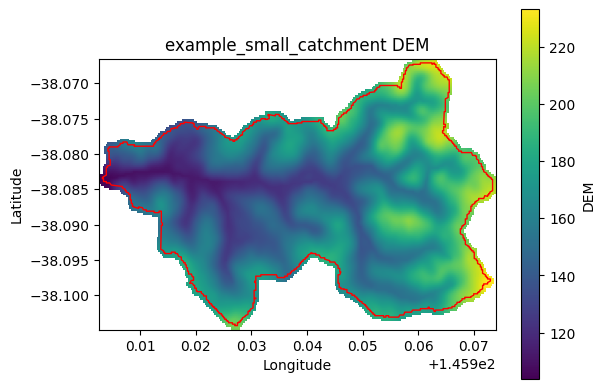

In [11]:
proj.plot_catchment_raster('Topography','DEM.tif')

2024-11-26 10:44:34,246 - fire_impacts.pre.project - INFO - Processing 1 catchments


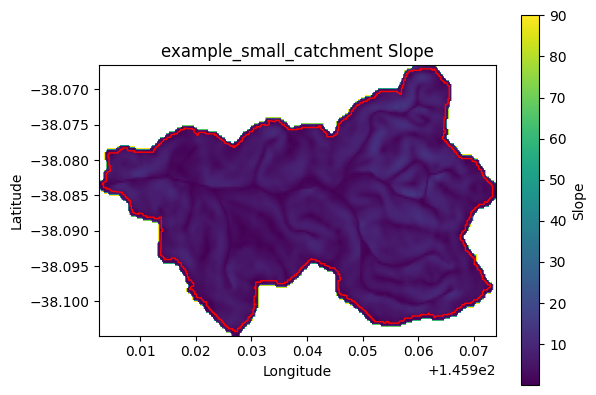

In [12]:
proj.plot_catchment_raster('Topography','Slope')

2024-11-26 10:44:34,497 - fire_impacts.pre.project - INFO - Processing 1 catchments


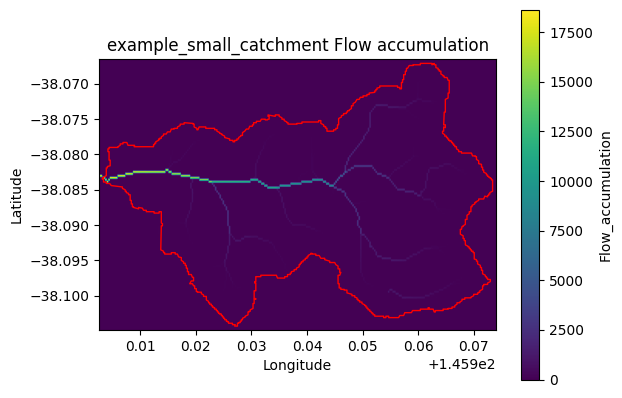

In [13]:
proj.plot_catchment_raster('Topography','Flow_accumulation')

## Aside: Function documentation

Most of the library functions include documentation describing the process, the function parameters and any return values

You can access the help in Jupyter with the `?` operator, for example:

```
topography.extract_headwaters?
```

In [14]:
topography.extract_headwaters?

Signature:
topography.extract_headwaters(
    project: fire_impacts.pre.project.FireImpactsProject,
    name: str = None,
    threshold_m2: float = 20000,
    crs_unit_to_metres: float = None,
)
Docstring:
Delinate headwaters for a catchment based on a flow accumulation threshold.

Parameters:
- project (dict): Dictionary containing the project folder structure.
- name (str): Name of the catchment to process. If None, process all catchments.
- threshold_m2 (float): Threshold area in square meters for headwaters. Default is 20,000 m^2.

Writes:
- Headwaters.shp: Shapefile containing the headwaters polygons.
- Headwaters.tif: Raster file containing the headwaters polygons.
- Headwaters.csv: CSV file containing the headwaters summary
- Flow_accumulation.tif: Raster file containing the flow accumulation data.
- Stream_Network.tif: Raster file containing the stream network data.
- Slope.tif: Raster file containing the slope data.

Returns:
- pd.DataFrame: DataFrame containing the headwaters

## Fire Severity

In [15]:
fire_start_date = '2019-01-15'  # Set fire start date (the date that fire started)
fire_end_date = '2019-03-07'    # Set fire end date (the date that fire ended)

In [16]:
severity.calculate_fire_severity(
    project=proj,
    catchment=None,
    fire_start_date=fire_start_date,
    fire_end_date=fire_end_date,
)


2024-11-26 10:44:34,771 - fire_impacts.pre.project - INFO - Processing 1 catchments
2024-11-26 10:44:34,860 - fire_impacts.pre.severity - INFO - No start date for pre-fire data provided. Defaulting to 90 days before fire start date.
2024-11-26 10:44:34,861 - fire_impacts.pre.severity - INFO - No end date for post-fire data provided. Defaulting to 90 days after fire end date.
2024-11-26 10:44:34,861 - fire_impacts.pre.severity - INFO - Bounding box not provided. Calculating bounding box from shapefile with 10km buffer.
2024-11-26 10:44:34,876 - fire_impacts.pre.severity - INFO - Calculating Pre_fire NBR for example_small_catchment
2024-11-26 10:44:35,160 - fire_impacts.pre.severity - INFO - Found: 22 datasets
2024-11-26 10:44:47,040 - fire_impacts.pre.severity - INFO - Calculating Post_fire NBR for example_small_catchment
2024-11-26 10:44:47,298 - fire_impacts.pre.severity - INFO - Found: 24 datasets
2024-11-26 10:44:58,689 - fire_impacts.pre.severity - INFO - Calculating dNBR for examp

{'example_small_catchment': None}

## Soils



In [17]:
ARIDITY=r'../test_data/Aridity_PT.tif'

In [18]:
soil.download_soil_data(proj)

# Extract aridity data for each catchment
soil.extract_aridity_data(proj,aridity_raster=ARIDITY)

2024-11-26 10:44:58,715 - fire_impacts.pre.project - INFO - Processing 1 catchments
2024-11-26 10:44:58,729 - fire_impacts.pre.soil - INFO - Processing catchment: example_small_catchment with bounding box [145.8131099099099, -38.194390090090096, 146.06349009009008, -37.97700990990991]
2024-11-26 10:45:06,952 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:4326 to EPSG:4326
2024-11-26 10:45:06,954 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2024-11-26 10:45:06,955 - fire_impacts.pre.util - INFO - Reprojecting clipped raster to: ./fire-impacts-data/Catchments/example_small_catchment/Soils/SILT/SLT_000_005_EV_N_P_AU_NAT_C.tif
2024-11-26 10:45:06,974 - fire_impacts.pre.soil - INFO - Downloaded SILT data saved as SLT_000_005_EV_N_P_AU_NAT_C.tif
2024-11-26 10:45:07,195 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:4326 to EPSG:4326
2024-11-26 10:45:07,197 - rasterio._env - WARNING - CPLE_NotSupported in dr

## RUSLE



In [19]:
c_factor_path='../test_data/c_factor_g94.tif'
k_factor_path='../test_data/k_factor_g94.tif'


In [20]:
rusle.compute_adjusted_k_c(proj,catchment=None,c_factor_fn=c_factor_path,k_factor_fn=k_factor_path)

2024-11-26 10:45:43,388 - fire_impacts.pre.project - INFO - Processing 1 catchments
/home/joelrahman/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/pre/util.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  catchment = catchment.to_crs(raster_crs).buffer(raster_res[0]*2)  # Buffer the shapefile by 2 pixels to ensure it covers the raster
2024-11-26 10:45:43,653 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:4283 to EPSG:4326
2024-11-26 10:45:43,673 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2024-11-26 10:45:43,674 - fire_impacts.pre.util - INFO - Reprojecting clipped raster to: ./fire-impacts-data/Catchments/example_small_catchment/Erodibility/C_factor.tif
/home/joelrahman/src/projects/WaterRA_Bushfire_Modeling/fire_impacts/pre/util.py:34: UserWarning: Geometry is in a ge

In [21]:

results = rusle.compute_lsi(proj)


2024-11-26 10:45:43,887 - fire_impacts.pre.project - INFO - Processing 1 catchments
2024-11-26 10:45:43,888 - fire_impacts.pre.rusle - INFO - Computed LSI for catchment: example_small_catchment
2024-11-26 10:45:43,970 - fire_impacts.pre.rusle - INFO - LS factor computed for catchment: example_small_catchment


## Summary information for Fire Severity

In [22]:
summary = project.summary_stats(proj)

2024-11-26 10:45:43,974 - fire_impacts.pre.project - INFO - Processing 1 catchments
2024-11-26 10:45:43,987 - fire_impacts.pre.project - INFO - Processing 246 polygons for 27 layers in example_small_catchment
2024-11-26 10:45:43,988 - root - INFO - Processing Slope from Slope.tif
2024-11-26 10:45:44,583 - root - INFO - Processing dNBR from dNBR.tif
2024-11-26 10:45:45,022 - root - INFO - Processing Aridity from Aridity.tif
2024-11-26 10:45:45,385 - root - INFO - Processing SLT_000_005_EV_N_P_AU_NAT_C from SLT_000_005_EV_N_P_AU_NAT_C.tif
2024-11-26 10:45:45,967 - root - INFO - Processing SLT_000_005_95_N_P_AU_NAT_C from SLT_000_005_95_N_P_AU_NAT_C.tif
2024-11-26 10:45:46,548 - root - INFO - Processing SLT_000_005_05_N_P_AU_NAT_C from SLT_000_005_05_N_P_AU_NAT_C.tif
2024-11-26 10:45:47,165 - root - INFO - Processing SLT_005_015_EV_N_P_AU_NAT_C from SLT_005_015_EV_N_P_AU_NAT_C.tif
2024-11-26 10:45:47,746 - root - INFO - Processing SLT_005_015_95_N_P_AU_NAT_C from SLT_005_015_95_N_P_AU_NAT

In [24]:
summary['example_small_catchment']

,ID,Slope_mean,Slope_max,Slope_min,Slope_median,Slope_std,dNBR_mean,dNBR_max,dNBR_min,dNBR_median,...,BDW_005_015_95_N_P_AU_NAT_C_mean,BDW_005_015_95_N_P_AU_NAT_C_max,BDW_005_015_95_N_P_AU_NAT_C_min,BDW_005_015_95_N_P_AU_NAT_C_median,BDW_005_015_95_N_P_AU_NAT_C_std,BDW_005_015_05_N_P_AU_NAT_C_mean,BDW_005_015_05_N_P_AU_NAT_C_max,BDW_005_015_05_N_P_AU_NAT_C_min,BDW_005_015_05_N_P_AU_NAT_C_median,BDW_005_015_05_N_P_AU_NAT_C_std
0,1,7.277140,10.805540,2.985693,7.477023,2.572590,None,None,None,None,...,1.436392,1.505481,1.399522,1.436125,0.035910,1.045070,1.115417,1.007285,1.050739,0.037735
1,2,8.470322,11.824585,2.710411,9.024028,2.964884,None,None,None,None,...,1.434438,1.487531,1.401288,1.420761,0.034777,1.035919,1.096408,0.994076,1.014847,0.041856
2,3,4.347613,6.730673,1.397475,4.364116,1.467525,None,None,None,None,...,1.447419,1.467563,1.417466,1.454330,0.015486,1.039523,1.063351,1.011160,1.044111,0.015006
3,4,6.134277,9.783648,1.067913,6.166992,2.433226,None,None,None,None,...,1.459871,1.509481,1.413550,1.457714,0.033720,1.066624,1.131821,1.012214,1.058584,0.041162
4,5,59.989311,90.000000,0.518340,90.000000,41.101339,None,None,None,None,...,1.478642,1.508911,1.464654,1.474462,0.014466,1.086753,1.098315,1.061297,1.092086,0.011220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,242,59.681752,90.000000,1.166650,90.000000,41.517994,None,None,None,None,...,1.484926,1.500442,1.463855,1.488046,0.013975,1.091510,1.106087,1.069354,1.094382,0.013124
242,243,50.271368,90.000000,1.892720,90.000000,43.522062,None,None,None,None,...,1.474521,1.496790,1.451440,1.476068,0.019979,1.090883,1.107739,1.065235,1.094519,0.015481
243,244,44.884541,90.000000,2.235763,5.131558,42.804147,None,None,None,None,...,1.467089,1.485945,1.439771,1.464640,0.011831,1.076133,1.088792,1.046577,1.073056,0.010529
244,245,37.604820,90.000000,0.756084,1.574196,43.596001,None,None,None,None,...,1.474225,1.492886,1.456588,1.477753,0.011592,1.087211,1.102749,1.072942,1.082390,0.011855
